In [ ]:
# =============================================================================
# Projeto : AuditAI Senado: Transparência e Análise Parlamentar com IA
# Disciplina: Inteligência Artificial - 7º semestre - Ciência da Computação
# Instituição: Universidade Presbiteriana Mackenzie - Faculdade de Computação
#              e Informática (FCI)
# Professor : Prof. Dr. Ivan Carlos Alcântara de Oliveira
#
# Integrantes (nome - RA - e-mail):
#   - Andrey Bezerra Virgínio dos Santos - 10420696 - 10420696@mackenzista.com.br
#   - Igor Silva Araujo                  - 10428505 - 10428505@mackenzista.com.br
#   - Julia Vitória Bomfim do Nascimento - 10425604 - 10425604@mackenzista.com.br
#   - William Saran dos Santos Junior    - 10420128 - 10420128@mackenzista.com.br
#
# Arquivo : notebooks/01_analise_exploratoria_preparacao.ipynb
# Síntese : Análise exploratória (EDA) e preparação do dataset "Brazilian
#           Senate Speeches" (Kaggle, versão LITE). O notebook (1) carrega os
#           100 mil discursos em streaming, (2) avalia estrutura e qualidade
#           (período, vazios, duplicatas, autores, partidos), (3) descreve as
#           distribuições (por ano, senador, partido, tamanho e papel de fala),
#           (4) faz uma sondagem léxica dos temas-exemplo da proposta para
#           justificar a busca semântica e (5) prepara a base de trechos
#           ("chunks") com metadados para a etapa de RAG do 2º bimestre.
# =============================================================================

# AuditAI Senado — Análise Exploratória e Preparação dos Dados (N1)

**Pergunta que o sistema final deverá responder:** *"Quais parlamentares mais abordaram o tema X e onde estão as evidências?"*

Para chegar lá (2º bimestre: busca semântica + RAG + agente), este notebook responde antes às perguntas sobre os **dados**:

1. O dataset cobre o período e os parlamentares esperados? Há vazios, duplicatas ou inconsistências?
2. Como os discursos se distribuem no tempo, entre senadores e partidos, e qual o seu tamanho?
3. Uma busca por palavras-chave é suficiente para encontrar discursos de um tema? (motivação para a busca semântica)
4. Como transformar os discursos em uma base de **trechos** adequada à recuperação semântica, preservando autor, data e fonte?

**Fonte:** LicoLabres (2024), *Brazilian Senate Speeches*, Kaggle — https://www.kaggle.com/datasets/licolabres/brazilian-senate-speeches-lite (licença CC BY-NC-SA 4.0). Arquivos usados: `fsdb_lite.json` (~935 MB), `partidos.json` e `externos.json`.

## 1. Configuração

In [2]:
import json, sys, time, unicodedata, re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))
from carregamento import carregar_discursos, carregar_lista_json
from preparacao import (limpar_texto, normalizar_busca, normalizar_partido,
                        hash_textos, aplicar_filtros, construir_trechos)
import gc, ctypes
def liberar_memoria():
    """Coleta lixo e devolve memória livre ao sistema (Linux)."""
    gc.collect()
    try: ctypes.CDLL("libc.so.6").malloc_trim(0)
    except OSError: pass

DIR_RAW = RAIZ / "data" / "raw"
DIR_PROC = RAIZ / "data" / "processed"
DIR_FIG = RAIZ / "resultados" / "figuras"
DIR_TAB = RAIZ / "resultados" / "tabelas"
DIR_AMOSTRA = RAIZ / "dataset" / "amostra"
for d in (DIR_PROC, DIR_FIG, DIR_TAB, DIR_AMOSTRA):
    d.mkdir(parents=True, exist_ok=True)

# aceita o arquivo original do Kaggle (.json) ou uma cópia compactada (.json.gz)
ARQ_LITE = next(p for p in [DIR_RAW / "fsdb_lite.json", DIR_RAW / "fsdb_lite.json.gz"] if p.exists())
print("Arquivo de entrada:", ARQ_LITE.name)

# Estilo dos gráficos: marcas finas, grade discreta, texto em tons neutros
AZUL, LARANJA, VERDE_AGUA = "#2a78d6", "#eb6834", "#1baf7a"
TEXTO, TEXTO2, GRADE = "#0b0b0b", "#52514e", "#e4e3df"
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "axes.edgecolor": TEXTO2, "axes.labelcolor": TEXTO, "xtick.color": TEXTO2, "ytick.color": TEXTO2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRADE, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "legend.frameon": False,
})
fmt_milhar = mpl.ticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))

def salvar(fig, nome):
    """Salva a figura em PNG (README/GitHub) e PDF (artigo em LaTeX)."""
    fig.savefig(DIR_FIG / f"{nome}.png")
    fig.savefig(DIR_FIG / f"{nome}.pdf")

METRICAS = {}  # números-chave exportados para o artigo (seção 8)
def br(n, casas=0):
    """Formata número no padrão brasileiro (1.234,5)."""
    s = f"{n:,.{casas}f}"
    return s.replace(",", "X").replace(".", ",").replace("X", ".")

Arquivo de entrada: fsdb_lite.json.gz


## 2. Carregamento

O `fsdb_lite.json` é um único objeto JSON `{CODIGO_DO_DISCURSO: registro}` de ~935 MB. Em vez de `json.load` (que precisaria de vários GB de RAM), `carregar_discursos` usa **ijson** para ler um discurso por vez e já "achatar" cada registro em uma linha:

| Campo original | Coluna(s) no DataFrame |
|---|---|
| `URL`, `Data` | `url`, `data`, `ano` |
| `Autor.Codigo`, `Autor.NomeSimples`, `Autor.Partido` | `autor_codigo`, `autor_nome`, `partido` |
| `Texto.Autoral[autor]` | `texto_autoral` (parágrafos unidos por `\n`), `autoral_palavras` |
| `Texto.Apartes / Presidencial / Externos` | nº de oradores e de palavras de cada papel |

In [3]:
t0 = time.time()
df = carregar_discursos(ARQ_LITE)
partidos_ref = carregar_lista_json(DIR_RAW / "partidos.json")   # {senador: partido}
externos = set(carregar_lista_json(DIR_RAW / "externos.json"))  # [não-senadores]
print(f"{len(df):,} discursos carregados em {time.time()-t0:.0f} s")
df.head(3)

100,667 discursos carregados em 17 s


,codigo,url,data,autor_codigo,autor_nome,partido,autoral_n_chaves,autor_em_autoral,texto_autoral,autoral_n_paragrafos,autoral_palavras,apartes_n_oradores,apartes_palavras,presidencial_n_oradores,presidencial_palavras,externos_n_oradores,externos_palavras,ano
0,143815,https://www25.senado.leg.br/web/atividade/pron...,1994-01-10,39,josaphat marinho,PFL,1,True,"Sr. Presidente, Srs. Senadores, o programa ela...",33,1536,3,1728,0,0,0,0,1994
1,143810,https://www25.senado.leg.br/web/atividade/pron...,1994-01-06,39,josaphat marinho,PFL,1,True,"Sr. Presidente, Srs. Senadores, é notória a cr...",13,634,2,335,0,0,0,0,1994
2,163747,https://www25.senado.leg.br/web/atividade/pron...,1995-02-22,39,josaphat marinho,PFL,1,True,"Sr. Presidente, Srªs e Srs. Senadores, vou tra...",34,1386,6,1749,1,45,0,0,1995


## 3. Estrutura e qualidade dos dados
### 3.1 Visão geral

In [4]:
visao = pd.Series({
    "Discursos (registros)": len(df),
    "Data mínima": df["data"].min().date(),
    "Data máxima": df["data"].max().date(),
    "Parlamentares (autores distintos)": df["autor_nome"].nunique(),
    "Rótulos de partido distintos (brutos)": df["partido"].nunique(),
    "Palavras no texto autoral (total)": int(df["autoral_palavras"].sum()),
})
METRICAS.update({
    "n_discursos": len(df), "data_min": str(df["data"].min().date()), "data_max": str(df["data"].max().date()),
    "n_autores": int(df["autor_nome"].nunique()), "n_partidos_brutos": int(df["partido"].nunique()),
    "palavras_autoral_total": int(df["autoral_palavras"].sum()),
})
visao.to_frame("valor")

,valor
Discursos (registros),100667
Data mínima,1980-12-05
Data máxima,2024-03-07
Parlamentares (autores distintos),486
Rótulos de partido distintos (brutos),61
Palavras no texto autoral (total),107127360


### 3.2 Cobertura temporal

A página do dataset informa "1988 a 2024", mas a contagem por ano mostra que a cobertura efetiva é **1994 a março de 2024**: há apenas 1 registro em 1980 e 1 em 1988 (datas atípicas), 1994 e 2024 são anos parciais. Isso muda o recorte que o artigo deve declarar.

In [5]:
por_ano = df.groupby("ano").size()
print(por_ano.to_string())
anos_completos = por_ano.loc[1995:2023]
METRICAS.update({
    "n_datas_atipicas": int((df["ano"] < 1994).sum()),
    "n_1994": int(por_ano.get(1994, 0)), "n_2024": int(por_ano.get(2024, 0)),
    "media_ano_1995_2023": float(anos_completos.mean()),
    "ano_min_count": int(anos_completos.idxmin()), "min_count": int(anos_completos.min()),
    "ano_max_count": int(anos_completos.idxmax()), "max_count": int(anos_completos.max()),
})

ano
1980       1
1988       1
1994     414
1995    2273
1996    3026
1997    2713
1998    1702
1999    2566
2000    2495
2001    2975
2002    1748
2003    4129
2004    3768
2005    5375
2006    5262
2007    4478
2008    4706
2009    4678
2010    2842
2011    4792
2012    3533
2013    5321
2014    2471
2015    3507
2016    3387
2017    2986
2018    2209
2019    3035
2020     849
2021    4418
2022    4232
2023    4517
2024     258


### 3.3 Texto autoral vazio

Cada registro separa o texto por **papel de fala**. Para a pergunta do projeto interessa o texto **Autoral** — as falas do próprio autor do pronunciamento. Registros sem texto autoral não podem ser atribuídos ao parlamentar.

In [6]:
vazio = df["autoral_palavras"] == 0
print(f"Discursos sem texto autoral: {vazio.sum():,} ({vazio.mean():.1%})")
print("Nº de chaves em Texto.Autoral:", df["autoral_n_chaves"].value_counts().to_dict())
v = df[vazio]
print(f"  - destes, com fala Presidencial: {(v['presidencial_palavras']>0).mean():.1%}")
print(f"  - com Apartes: {(v['apartes_palavras']>0).mean():.1%}")
print(f"  - sem nenhum texto em nenhum papel: {((v[['apartes_palavras','presidencial_palavras','externos_palavras']].sum(axis=1))==0).mean():.1%}")
METRICAS.update({"n_vazios": int(vazio.sum()), "pct_vazios": float(vazio.mean()),
                 "pct_vazios_com_presidencial": float((v['presidencial_palavras']>0).mean())})
del v; liberar_memoria()

Discursos sem texto autoral: 9,979 (9.9%)
Nº de chaves em Texto.Autoral: {1: 90688, 0: 9979}


  - destes, com fala Presidencial: 67.5%
  - com Apartes: 36.3%
  - sem nenhum texto em nenhum papel: 0.7%


**Interpretação.** Os registros vazios não são "discursos perdidos" ao acaso: dois terços deles têm falas classificadas como *Presidencial*, isto é, o parlamentar estava presidindo a sessão (ex.: presidentes do Senado). Como a pergunta do projeto é sobre o que o parlamentar **discursou**, esses registros serão excluídos da base de busca — limitação registrada no artigo.

### 3.4 Duplicatas e consistência de identificadores

In [7]:
dup_texto = hash_textos(df.loc[~vazio, "texto_autoral"]).duplicated().sum()
print("Códigos duplicados:", df["codigo"].duplicated().sum())
print("URLs duplicadas:", df["url"].duplicated().sum())
print("Textos autorais idênticos (não vazios):", dup_texto)
print("Códigos de autor com mais de um nome:", (df.groupby("autor_codigo")["autor_nome"].nunique() > 1).sum())
METRICAS["n_textos_duplicados"] = int(dup_texto)

Códigos duplicados: 0
URLs duplicadas: 0
Textos autorais idênticos (não vazios): 380
Códigos de autor com mais de um nome: 0


### 3.5 Autores × lista de "externos"

O arquivo `externos.json` lista pessoas **não-senadoras** que falaram no Senado (ministros, convidados), e a documentação sugere usá-lo para filtrar autores. Antes de aplicar o filtro, verificamos quem seria removido.

In [8]:
em_ext = df["autor_nome"].isin(externos)
print(f"Discursos cujo autor está em externos.json: {em_ext.sum():,} ({df.loc[em_ext,'autor_nome'].nunique()} autores)")
print(df.loc[em_ext, "autor_nome"].value_counts().head(10).to_string())
print(f"\nAutores presentes em partidos.json: {df['autor_nome'].isin(partidos_ref.keys()).mean():.1%} dos discursos")
METRICAS.update({"n_autor_externos": int(em_ext.sum()), "n_autores_externos": int(df.loc[em_ext,'autor_nome'].nunique())})

Discursos cujo autor está em externos.json: 629 (35 autores)
autor_nome
major olimpio            61
jose ignacio ferreira    56
lindberg cury            56
joao franca              52
paulo souto              49
jose alves               46
leonel paiva             33
luzia toledo             32
jose bianco              29
otoniel machado          28

Autores presentes em partidos.json: 99.4% dos discursos


**Decisão.** Os nomes encontrados (ex.: *major olimpio*, *paulo souto*, *luzia toledo*) são de parlamentares que exerceram mandato no Senado — vários deles suplentes —, e que provavelmente também aparecem como oradores externos em outras sessões (antes ou depois do mandato). Como o campo `Autor` vem do registro oficial do pronunciamento, **não** usamos `externos.json` para excluir autores; aplicar o filtro removeria discursos legítimos de senadores.

### 3.6 Rótulos de partido

In [9]:
brutos = df["partido"].value_counts()
df["partido_norm"] = df["partido"].map(normalizar_partido)
print(f"Rótulos brutos: {brutos.size} -> após normalizar grafia: {df['partido_norm'].nunique()}")
print("Exemplos de variações de grafia:", [s for s in brutos.index if s != s.strip()][:6], "| 'PC DO B' x 'PCdoB' | 'PODE' x 'PODEMOS'")
METRICAS["n_partidos_norm"] = int(df["partido_norm"].nunique())

Rótulos brutos: 61 -> após normalizar grafia: 42
Exemplos de variações de grafia: ['PMDB     ', 'PSDB     ', 'PT       ', 'PDT      ', 'PSB      ', 'PFL      '] | 'PC DO B' x 'PCdoB' | 'PODE' x 'PODEMOS'


Foram corrigidas apenas **variações de grafia** (espaços à direita, "PC DO B" × "PCdoB", "PODE" × "PODEMOS", "S/Partido" × "S/PARTIDO"). Renomeações históricas (PMDB→MDB, PFL→DEM→UNIÃO, PR→PL, PPS→CIDADANIA, PRB→REPUBLICANOS) foram **mantidas**, porque o campo registra o partido *na data do discurso* — unificá-las seria uma interpretação política, não uma limpeza.

## 4. Distribuições
### 4.1 Discursos por ano

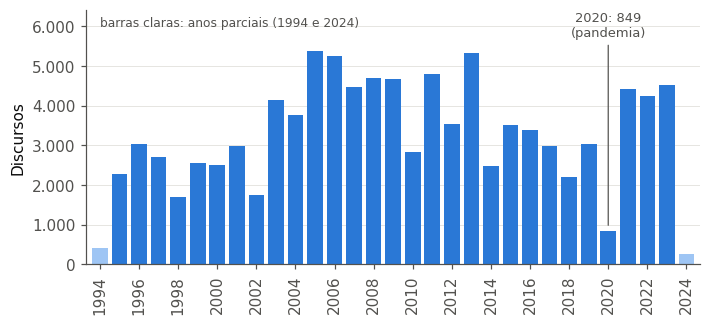

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 3.0))
anos = por_ano.loc[1994:2024]
cores = [AZUL if 1995 <= a <= 2023 else "#9ec5f4" for a in anos.index]
ax.bar(anos.index, anos.values, color=cores, width=0.8)
ax.set_ylabel("Discursos"); ax.yaxis.set_major_formatter(fmt_milhar)
ax.set_xticks(range(1994, 2025, 2)); ax.tick_params(axis="x", rotation=90)
ax.grid(axis="x", visible=False)
a20 = int(anos.loc[2020])
ax.annotate(f"2020: {br(a20)}\n(pandemia)", xy=(2020, a20 + 60), xytext=(2020, 5750), ha="center",
            fontsize=8.5, color=TEXTO2, arrowprops=dict(arrowstyle="-", color=TEXTO2, lw=0.8))
ax.text(1994, 6000, "barras claras: anos parciais (1994 e 2024)", fontsize=8, color=TEXTO2)
ax.set_xlim(1993.3, 2024.7); ax.set_ylim(0, 6400)
salvar(fig, "fig1_discursos_por_ano"); plt.show()

A produção anual varia bastante (de 849 a 5.375 discursos nos anos completos). Vários anos de eleições gerais (1998, 2002, 2010, 2014 e 2018) estão entre os de menor produção — embora 2006 e 2022 não sigam o padrão —, e 2020 é o ponto mais baixo da série, ano das sessões deliberativas remotas da pandemia. Para a solução, isso significa que **contagens absolutas de menções por ano precisam ser normalizadas** pelo volume de discursos do ano.

### 4.2 Concentração por parlamentar

481 autores com texto autoral; mediana = 81 discursos/autor
Os 10% mais ativos (49 autores) concentram 47.3% dos discursos


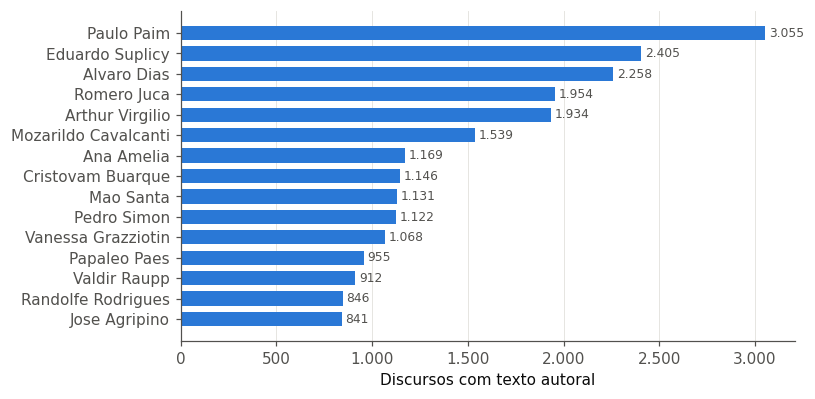

In [11]:
por_autor = df.loc[~vazio, "autor_nome"].value_counts()
n10 = int(np.ceil(0.10 * len(por_autor)))
share_top10 = por_autor.iloc[:n10].sum() / por_autor.sum()
print(f"{len(por_autor)} autores com texto autoral; mediana = {por_autor.median():.0f} discursos/autor")
print(f"Os 10% mais ativos ({n10} autores) concentram {share_top10:.1%} dos discursos")
METRICAS.update({"n_autores_com_texto": int(len(por_autor)), "mediana_disc_autor": float(por_autor.median()),
                 "n_top10pct": n10, "share_top10pct": float(share_top10), "max_disc_autor": int(por_autor.iloc[0])})

top = por_autor.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(7.2, 3.9))
ax.barh([n.title() for n in top.index], top.values, color=AZUL, height=0.7)
for y, v_ in enumerate(top.values):
    ax.text(v_ + 20, y, br(v_), va="center", fontsize=8, color=TEXTO2)
ax.set_xlabel("Discursos com texto autoral"); ax.xaxis.set_major_formatter(fmt_milhar)
ax.grid(axis="y", visible=False)
salvar(fig, "fig2_top_parlamentares"); plt.show()

A atividade é bastante concentrada: poucos senadores com longos mandatos respondem por grande parte do corpus. Consequência para o agente: um ranking por **contagem bruta** de discursos sobre um tema tende a favorecer quem mais discursa em geral. Na N2, além da contagem, será apresentada a **proporção** de discursos do parlamentar que tratam do tema.

### 4.3 Partidos (grafia normalizada)

In [12]:
tab_part = (df.loc[~vazio, "partido_norm"].value_counts().head(10).rename("discursos").to_frame())
tab_part["%"] = (100 * tab_part["discursos"] / (~vazio).sum()).round(1)
tab_part.to_csv(DIR_TAB / "top10_partidos.csv")
tab_part

,discursos,%
partido_norm,,
PT,17224,19.0
PSDB,15984,17.6
PMDB,15214,16.8
PFL,7532,8.3
PDT,4548,5.0
PP,3208,3.5
PSB,3033,3.3
PTB,2789,3.1
DEM,2747,3.0


### 4.4 Tamanho dos discursos (texto autoral)

count    90688.0
mean      1181.0
std       1007.0
min          1.0
5%         103.0
25%        442.0
50%        978.0
75%       1649.0
95%       2962.0
99%       4567.0
max      29586.0


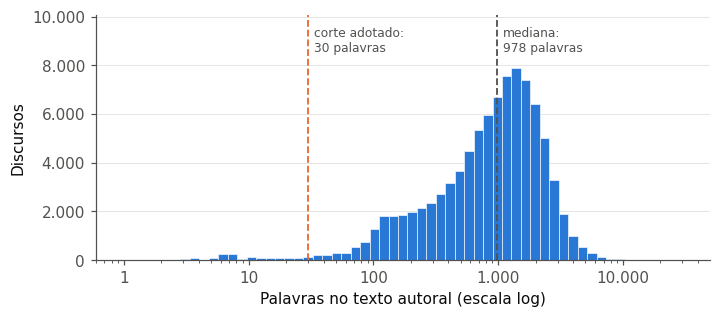

In [13]:
pal = df.loc[~vazio, "autoral_palavras"]
desc = pal.describe(percentiles=[.05, .25, .5, .75, .95, .99])
print(desc.round(0).to_string())
METRICAS.update({"pal_mediana": float(pal.median()), "pal_media": float(pal.mean()),
                 "pal_p25": float(pal.quantile(.25)), "pal_p75": float(pal.quantile(.75)),
                 "pal_p99": float(pal.quantile(.99)), "pal_max": int(pal.max()),
                 "n_menos30": int((pal < 30).sum())})

fig, ax = plt.subplots(figsize=(7.2, 2.9))
bins = np.logspace(0, np.log10(pal.max() + 1), 60)
ax.hist(pal, bins=bins, color=AZUL, edgecolor="white", linewidth=0.4)
ax.set_xscale("log"); ax.set_xlabel("Palavras no texto autoral (escala log)"); ax.set_ylabel("Discursos")
ax.yaxis.set_major_formatter(fmt_milhar)
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: br(x)))
ax.set_ylim(0, ax.get_ylim()[1] * 1.22)
for x, rot in [(30, "corte adotado:\n30 palavras"), (pal.median(), f"mediana:\n{br(pal.median())} palavras")]:
    ax.axvline(x, color=LARANJA if x == 30 else TEXTO2, lw=1.2, ls="--")
    ax.text(x * 1.12, ax.get_ylim()[1] * 0.95, rot, fontsize=8, color=TEXTO2, ha="left", va="top")
ax.grid(axis="x", visible=False)
salvar(fig, "fig3_tamanho_discursos"); plt.show()

In [14]:
# O que há na cauda curta? (inspeção manual que justificou o corte de 30 palavras)
curtos = df[(df["autoral_palavras"] > 0) & (df["autoral_palavras"] < 30)]
for t in curtos.sample(8, random_state=1)["texto_autoral"]:
    print("-", t[:150].replace("\n", " / "))

- Demonstrando a nossa alegria, eu concedo a palavra a V. Exª, que tem a permissão da Presidência para falar sentado.
- Sr. Presidente, o PT também vai orientar contrário, porque eu também entendo que é inoportuno o momento. Amanhã, no debate, na discussão, nós vamos fa
- Sr. Presidente, Srªs e Srs. Senadores,
- O Governo orienta o voto "não".
- Presidente, só para comunicar que na votação do Plenário, eu votei com a orientação da bancada, do meu bloco.
- O PL orienta o voto "não", Presidente.
- Presidente, a Oposição, "não".
- A minoria vota “sim”.


A distribuição é assimétrica (mediana de 978 palavras; 1% passa de 4,5 mil). Na cauda curta aparecem sobretudo **manifestações procedimentais** ("o partido orienta o voto sim", "pela ordem, Sr. Presidente"), que não carregam conteúdo temático e poluiriam a busca. Por isso adotamos o corte de **30 palavras**. Discursos longos, por outro lado, excedem o limite de entrada dos modelos de *embeddings*: é isso que motiva a **segmentação em trechos** (seção 6.3).

### 4.5 Composição por papel de fala

In [15]:
comp = pd.Series({
    "Autoral": df["autoral_palavras"].sum(),
    "Apartes": df["apartes_palavras"].sum(),
    "Presidencial": df["presidencial_palavras"].sum(),
    "Externos": df["externos_palavras"].sum(),
}).rename("palavras").to_frame()
comp["%"] = (100 * comp["palavras"] / comp["palavras"].sum()).round(1)
comp["% discursos com o papel"] = [round(100 * (df[c] > 0).mean(), 1) for c in
                                   ["autoral_palavras", "apartes_palavras", "presidencial_palavras", "externos_palavras"]]
METRICAS.update({f"pct_palavras_{k.lower()}": float(v) for k, v in comp["%"].items()})
comp.to_csv(DIR_TAB / "composicao_papeis.csv")
comp

,palavras,%,% discursos com o papel
Autoral,107127360,81.9,90.1
Apartes,18569245,14.2,25.9
Presidencial,4090075,3.1,21.0
Externos,1024245,0.8,1.1


Cerca de 18% das palavras de um "discurso" não são do seu autor (apartes de outros senadores, falas da Presidência e de convidados). Se o texto completo fosse indexado, uma fala de aparte seria atribuída ao autor do discurso — erro de atribuição grave num sistema de transparência. **Somente o texto autoral** entra na base de busca.

### 4.6 Vocabulário mais frequente

In [16]:
from nltk.corpus import stopwords  # requer: nltk.download("stopwords")
sw = {normalizar_busca(w) for w in stopwords.words("portuguese")}
amostra_vocab = df.loc[~vazio, "texto_autoral"].sample(20000, random_state=42)
cont = Counter()
for t in amostra_vocab:
    cont.update(w for w in re.findall(r"[a-z]{3,}", normalizar_busca(t)) if w not in sw)
top_vocab = pd.DataFrame(cont.most_common(25), columns=["termo", "frequência"])
top_vocab.to_csv(DIR_TAB / "top25_termos_amostra.csv", index=False)
top_vocab.T

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
termo,presidente,senador,brasil,governo,aqui,estado,porque,pais,hoje,todos,...,fazer,nacional,senado,sobre,ainda,entao,vai,quero,ter,casa
frequência,134313,79175,68448,65060,64580,58158,57844,57120,46760,46753,...,34892,34049,33605,33415,31560,29143,28516,28397,28208,27079


Mesmo sem *stopwords*, os termos mais frequentes são de **tratamento e procedimento** (*presidente, senador, senado, sr, exa…*), não de conteúdo. Isso ajuda a explicar por que abordagens por frequência de palavras (bag-of-words) tendem a aproximar discursos pelo "ritual" parlamentar e não pelo tema — um argumento a favor de representações semânticas (*embeddings*) e de filtros por relevância.

## 5. Sondagem temática léxica (motivação para a busca semântica)

A proposta usa como exemplo a pergunta *"Quais parlamentares mais abordaram violência contra a mulher?"*. Aqui medimos o que uma **busca por palavras-chave** encontraria para os temas citados na proposta, comparando:

- **Expressão exata**: o nome do tema (ex.: "violência contra a mulher");
- **Termos relacionados**: expressões que um especialista associaria ao tema (ex.: "feminicídio", "Lei Maria da Penha", "medidas protetivas").

A busca é feita em minúsculas e sem acentos. Os termos relacionados foram escolhidos pelo grupo e **não** garantem relevância — o objetivo é medir quanto o resultado depende do vocabulário escolhido.

In [17]:
TEMAS = {
    "Violência contra a mulher": (["violencia contra a mulher"],
        ["violencia contra a mulher", "violencia contra as mulheres", "violencia domestica", "feminicidio",
         "maria da penha", "medida protetiva", "medidas protetivas", "violencia de genero"]),
    "Meio ambiente": (["meio ambiente"],
        ["meio ambiente", "desmatamento", "mudanca climatica", "mudancas climaticas", "aquecimento global",
         "queimadas", "desenvolvimento sustentavel", "efeito estufa"]),
    "Inteligência artificial": (["inteligencia artificial"],
        ["inteligencia artificial", "aprendizado de maquina", "machine learning", "chatgpt", "deepfake", "redes neurais"]),
    "Educação": (["educacao"],
        ["educacao", "ensino", "escola", "escolas", "professores", "universidade", "universidades"]),
    "Saúde": (["saude"],
        ["saude", "sus", "hospital", "hospitais", "medicos", "vacina", "vacinas"]),
}
base = df.loc[~vazio, ["codigo", "ano", "autor_nome"]].reset_index(drop=True)
textos = df.loc[~vazio, "texto_autoral"]

def rx(termos):
    return re.compile(r"\b(?:" + "|".join(re.escape(t) for t in termos) + r")\b")

# padrões a testar: (tema, exato/relacionados) + expressões da série temporal
PADROES = {}
for tema, (exatos, relacionados) in TEMAS.items():
    PADROES[(tema, "exato")] = rx(exatos)
    PADROES[(tema, "rel")] = rx(relacionados)
PADROES["vcm"] = rx(["violencia contra a mulher", "violencia contra as mulheres"])
PADROES["fem"] = rx(["feminicidio", "feminicidios"])
PADROES["ia"] = rx(["inteligencia artificial"])

# normaliza e testa em lotes, guardando só os resultados booleanos (economiza memória)
achou = {k: np.zeros(len(base), dtype=bool) for k in PADROES}
LOTE = 5000
for ini in range(0, len(base), LOTE):
    lote = [normalizar_busca(t) for t in textos.iloc[ini:ini + LOTE]]
    for k, padrao in PADROES.items():
        achou[k][ini:ini + len(lote)] = [padrao.search(t) is not None for t in lote]
del lote, textos; liberar_memoria()

linhas = []
for tema in TEMAS:
    m_ex, m_rel = achou[(tema, "exato")], achou[(tema, "rel")]
    linhas.append({"tema": tema, "expressão exata": int(m_ex.sum()), "termos relacionados": int(m_rel.sum()),
                   "acréscimo (%)": round(100 * (m_rel.sum() - m_ex.sum()) / max(m_ex.sum(), 1), 1),
                   "% do corpus (relacionados)": round(100 * m_rel.mean(), 1)})
tab_temas = pd.DataFrame(linhas).set_index("tema")
tab_temas.to_csv(DIR_TAB / "sondagem_tematica.csv")
METRICAS["temas"] = tab_temas.reset_index().to_dict(orient="records")
tab_temas

,expressão exata,termos relacionados,acréscimo (%),% do corpus (relacionados)
tema,,,,
Violência contra a mulher,815,1708,109.6,1.9
Meio ambiente,7221,9379,29.9,10.3
Inteligência artificial,75,75,0.0,0.1
Educação,21240,31626,48.9,34.9
Saúde,23451,26729,14.0,29.5


**Leitura.** Para temas com vocabulário especializado, a expressão exata encontra menos da metade (violência contra a mulher: 815 × 1.708) ou cerca de três quartos (meio ambiente) dos discursos achados com termos relacionados — uma busca literal **perde** discursos, e o resultado depende de quem escolhe as palavras. "Inteligência artificial" é raro no corpus (75 discursos) e os termos relacionados não acrescentaram nada. Para temas amplos (educação, saúde), o problema se inverte: os termos aparecem em cerca de 30% a 35% de todos os discursos, muitas vezes de passagem, e a simples ocorrência **não indica** que o discurso trata do tema. Os dois efeitos justificam (i) a busca por **significado** (*embeddings*) e (ii) a recuperação no nível de **trechos** com ranqueamento, em vez de marcar o discurso inteiro por uma palavra.

Anos em que 'feminicídio' supera 'violência contra a(s) mulher(es)': [2020, 2023]


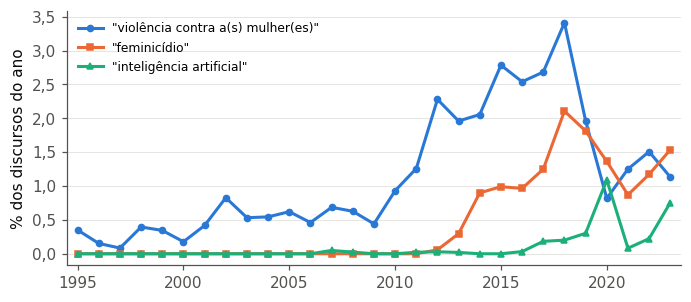

In [18]:
# Evolução temporal: % de discursos do ano que mencionam cada expressão
def serie(chave):
    return pd.Series(achou[chave]).groupby(base["ano"].values).mean().loc[1995:2023] * 100

s_vcm, s_fem, s_ia = serie("vcm"), serie("fem"), serie("ia")
print("Anos em que 'feminicídio' supera 'violência contra a(s) mulher(es)':", [int(a) for a in s_fem.index[s_fem > s_vcm]])
METRICAS["anos_fem_supera_vcm"] = [int(a) for a in s_fem.index[s_fem > s_vcm]]
METRICAS.update({"primeiro_ano_feminicidio": int(s_fem[s_fem > 0.2].index.min()),
                 "fem_2023": float(s_fem.loc[2023]), "ia_2023": float(s_ia.loc[2023]),
                 "ia_2018": float(s_ia.loc[2018]), "vcm_2023": float(s_vcm.loc[2023])})

fig, ax = plt.subplots(figsize=(7.2, 3.0))
for s_, cor, mk, rot in [(s_vcm, AZUL, "o", '"violência contra a(s) mulher(es)"'), (s_fem, LARANJA, "s", '"feminicídio"'),
                         (s_ia, VERDE_AGUA, "^", '"inteligência artificial"')]:
    ax.plot(s_.index, s_.values, color=cor, lw=2, marker=mk, ms=4, label=rot)
ax.set_ylabel("% dos discursos do ano"); ax.set_xlim(1994.5, 2023.5)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: br(x, 1)))
ax.legend(loc="upper left", fontsize=8)
ax.grid(axis="x", visible=False)
salvar(fig, "fig4_evolucao_termos"); plt.show()

O termo **"feminicídio"** é praticamente ausente do corpus até 2012, cresce a partir de 2013 — período de tramitação do projeto que resultou na Lei 13.104/2015, que tipificou o crime — e supera a expressão genérica em 2020 e 2023 (anos impressos acima). **"Inteligência artificial"** é quase ausente até 2016 e cresce a partir de 2017 (o pico de 2020 deve ser lido com cautela: foi o ano com menos discursos, o que infla percentuais). Isso é *deriva de vocabulário*: o mesmo assunto é nomeado de formas diferentes ao longo de 30 anos, e uma busca literal fixa ficaria defasada. É mais um argumento a favor da recuperação semântica.

In [19]:
# Linha de base léxica para a pergunta-exemplo da proposta.
# ATENÇÃO: mencionar o tema NÃO equivale a posicionamento político.
m = achou[("Violência contra a mulher", "rel")]
cont_aut = base.loc[m].groupby("autor_nome").size()
tot_aut = base.groupby("autor_nome").size()
baseline = (pd.DataFrame({"discursos que mencionam": cont_aut, "total de discursos": tot_aut.loc[cont_aut.index]})
            .assign(**{"% dos discursos": lambda d: (100 * d.iloc[:, 0] / d.iloc[:, 1]).round(1)})
            .sort_values("discursos que mencionam", ascending=False).head(10))
baseline.index = baseline.index.str.title()
baseline.to_csv(DIR_TAB / "baseline_lexico_vcm_top10.csv")
METRICAS["n_disc_vcm_relacionados"] = int(m.sum()); METRICAS["n_autores_vcm"] = int((cont_aut > 0).sum())
baseline

,discursos que mencionam,total de discursos,% dos discursos
autor_nome,,,
Paulo Paim,193,3055,6.3
Vanessa Grazziotin,96,1068,9.0
Angela Portela,83,628,13.2
Serys Slhessarenko,64,476,13.4
Ana Rita,56,176,31.8
Rose De Freitas,49,319,15.4
Regina Sousa,45,144,31.2
Lidice Da Mata,43,443,9.7
Gleisi Hoffmann,34,446,7.6


Esta tabela é a resposta que um sistema **puramente léxico** daria à pergunta-exemplo. Ela servirá como **linha de base** para a avaliação da N2: o agente com busca semântica deve (i) recuperar discursos relevantes que não usam essas palavras e (ii) descartar menções de passagem, apresentando o trecho que comprova cada resultado. Note também como a coluna "% dos discursos" muda a leitura em relação à contagem absoluta (efeito da concentração vista em 4.2).

## 6. Preparação dos dados para a busca semântica (RAG)
### 6.1 Limpeza do texto autoral
`limpar_texto` normaliza Unicode (NFC), remove rótulos de orador que sobraram da página ("O SR. FULANO (PARTIDO - UF) –"), cabeçalhos entre parênteses ("Sem revisão do orador") e anotações taquigráficas, e normaliza espaços. **Não** removemos acentos nem *stopwords* do texto que vai para os *embeddings*: modelos de linguagem usam essas informações.

In [20]:
del base, achou  # libera memória da sondagem
partes = [pd.Series([limpar_texto(t) for t in df["texto_autoral"].iloc[i:i + 5000]], dtype="str")
          for i in range(0, len(df), 5000)]   # em lotes, para economizar memória
df["texto_limpo"] = pd.concat(partes, ignore_index=True).values
del partes; liberar_memoria()
df["palavras_limpo"] = df["texto_limpo"].str.count(r"\S+").fillna(0).astype(int)  # contagem sem criar listas de palavras
alterados = (df["texto_limpo"] != df["texto_autoral"].str.strip()) & ~vazio
print(f"Textos alterados pela limpeza: {alterados.sum():,} ({alterados.sum()/(~vazio).sum():.1%} dos não vazios)")
METRICAS["n_alterados_limpeza"] = int(alterados.sum())
df = df.drop(columns=["texto_autoral"]); liberar_memoria()

Textos alterados pela limpeza: 1,242 (1.4% dos não vazios)


### 6.2 Filtros de qualidade

In [21]:
MIN_PALAVRAS = 30
dfp, relatorio = aplicar_filtros(df, min_palavras=MIN_PALAVRAS)
del df; liberar_memoria()
relatorio.to_csv(DIR_TAB / "relatorio_filtros.csv", index=False)
METRICAS.update({"n_final_discursos": int(len(dfp)), "n_final_autores": int(dfp["autor_nome"].nunique()),
                 "relatorio_filtros": relatorio.to_dict(orient="records"),
                 "final_data_min": str(dfp["data"].min().date()), "final_data_max": str(dfp["data"].max().date())})
relatorio

,etapa,discursos_restantes,removidos
0,Registros originais,100667,0
1,Remove texto autoral vazio,90688,9979
2,Remove textos autorais duplicados,90303,385
3,Remove discursos com menos de 30 palavras,89017,1286


Os dois registros com datas atípicas (1980 e 1988) não tinham texto autoral e saíram no primeiro filtro. O recorte final vai de 1994 a 2024.

### 6.3 Segmentação em trechos (*chunking*)

Modelos de *embeddings* têm limite de entrada (ex.: 512 *tokens* no multilingual-E5) e um vetor único para um discurso de 3 mil palavras "dilui" os assuntos. Por isso cada texto autoral é dividido em **trechos de até 250 palavras**, agrupando **sentenças inteiras** (para não cortar frases ao meio), com **sobreposição de até 50 palavras** entre trechos vizinhos (para não perder contexto na fronteira). Cada trecho herda os metadados do discurso — é isso que permitirá, na N2, **agrupar os resultados por parlamentar** e **citar a evidência** (URL oficial + data).

*Por que 250/50?* Trabalhos correlatos usam trechos de 100 a 512 *tokens* com 15–20% de sobreposição; 250 palavras ficam no meio dessa faixa e, em português, tendem a caber no limite de 512 *tokens*. O tamanho será reavaliado na N2 (a contagem exata em *tokens* depende do *tokenizer* do modelo escolhido).

In [22]:
t0 = time.time()
dfp["partido"] = dfp["partido_norm"]
trechos = construir_trechos(dfp, max_palavras=250, sobreposicao=50)
print(f"{len(trechos):,} trechos gerados em {time.time()-t0:.0f} s")
por_disc = trechos.groupby("codigo").size()
print(trechos["n_palavras"].describe(percentiles=[.05, .5, .95]).round(0).to_string())
METRICAS.update({"n_trechos": int(len(trechos)), "trechos_por_disc_mediana": float(por_disc.median()),
                 "trecho_pal_mediana": float(trechos["n_palavras"].median()),
                 "trecho_pal_p05": float(trechos["n_palavras"].quantile(.05)),
                 "trecho_pal_max": int(trechos["n_palavras"].max()),
                 "pct_disc_1_trecho": float((por_disc == 1).mean())})
trechos.head(3)

558,569 trechos gerados em 37 s
count    558569.0
mean        220.0
std          42.0
min           2.0
5%          112.0
50%         235.0
95%         249.0
max         250.0


,trecho_id,codigo,ordem,data,ano,autor_nome,partido,url,texto,n_palavras
0,143815_000,143815,0,1994-01-10,1994,josaphat marinho,PFL,https://www25.senado.leg.br/web/atividade/pron...,"Sr. Presidente, Srs. Senadores, o programa ela...",241
1,143815_001,143815,1,1994-01-10,1994,josaphat marinho,PFL,https://www25.senado.leg.br/web/atividade/pron...,"Creio mesmo que a matéria, por sua natureza, e...",236
2,143815_002,143815,2,1994-01-10,1994,josaphat marinho,PFL,https://www25.senado.leg.br/web/atividade/pron...,"O ilustre Ministro da Fazenda, sempre sorrindo...",231


### 6.4 Salvamento e amostras para o GitHub

In [23]:
# Bases completas (não versionadas no GitHub por tamanho; regeneradas por este notebook)
cols_disc = ["codigo", "url", "data", "ano", "autor_codigo", "autor_nome", "partido", "texto_limpo", "palavras_limpo"]
dfp[cols_disc].to_parquet(DIR_PROC / "discursos_preparados.parquet", index=False)
trechos.to_parquet(DIR_PROC / "trechos.parquet", index=False)

# Amostras pequenas (versionadas) para inspeção e testes rápidos
trechos.sample(2000, random_state=42).sort_values("trecho_id").to_csv(DIR_AMOSTRA / "amostra_trechos.csv", index=False)
dfp[cols_disc].sample(300, random_state=42).sort_values("codigo").to_csv(DIR_AMOSTRA / "amostra_discursos.csv", index=False)
for p in list(DIR_PROC.glob("*.parquet")) + list(DIR_AMOSTRA.glob("*.csv")):
    print(f"{p.relative_to(RAIZ)}: {p.stat().st_size/1e6:.1f} MB")

data/processed/_discursos_brutos.parquet: 376.0 MB
data/processed/trechos.parquet: 396.2 MB
data/processed/discursos_preparados.parquet: 375.2 MB
dataset/amostra/amostra_discursos.csv: 2.4 MB
dataset/amostra/amostra_trechos.csv: 3.1 MB


## 7. Síntese dos achados

| Achado | Consequência para a solução |
|---|---|
| Cobertura efetiva 1994–mar/2024 (não 1988), com 2 datas atípicas | Recorte declarado no artigo; datas atípicas removidas |
| ~10% dos registros sem texto autoral (maioria: parlamentar presidindo a sessão) | Excluídos da base; limitação documentada |
| ~18% das palavras são de outros oradores (apartes, Presidência, convidados) | Só o texto **Autoral** é indexado → evita atribuir fala a quem não a disse |
| `externos.json` contém suplentes que foram senadores | Lista **não** usada como filtro |
| Rótulos de partido com variações de grafia e renomeações | Grafia normalizada; renomeações mantidas (partido na data) |
| Atividade concentrada em poucos senadores | Ranking deve mostrar contagem **e** proporção |
| Busca literal perde discursos (termos especializados) e superestima temas amplos; vocabulário muda no tempo | Justifica busca semântica por trechos + ranqueamento; tabela léxica vira linha de base da avaliação |
| Discursos longos (mediana de 978 palavras) | Segmentação em trechos de ≤250 palavras com sobreposição |

**Próximos passos (N2):** gerar *embeddings* dos trechos, indexá-los (base vetorial), implementar o agente (interpretação da pergunta → busca → agrupamento por parlamentar → resposta com evidências via LLM/RAG), construir a interface e avaliar a recuperação contra a linha de base léxica.

## 8. Exportação das métricas usadas no artigo

In [24]:
def _conv(o):
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    return str(o)
(RAIZ / "resultados" / "metricas.json").write_text(json.dumps(METRICAS, ensure_ascii=False, indent=2, default=_conv), encoding="utf-8")
print(json.dumps({k: v for k, v in METRICAS.items() if not isinstance(v, list)}, ensure_ascii=False, indent=1, default=_conv))

{
 "n_discursos": 100667,
 "data_min": "1980-12-05",
 "data_max": "2024-03-07",
 "n_autores": 486,
 "n_partidos_brutos": 61,
 "palavras_autoral_total": 107127360,
 "n_datas_atipicas": 2,
 "n_1994": 414,
 "n_2024": 258,
 "media_ano_1995_2023": 3448.0344827586205,
 "ano_min_count": 2020,
 "min_count": 849,
 "ano_max_count": 2005,
 "max_count": 5375,
 "n_vazios": 9979,
 "pct_vazios": 0.0991288108317522,
 "pct_vazios_com_presidencial": 0.6749173263854094,
 "n_textos_duplicados": 380,
 "n_autor_externos": 629,
 "n_autores_externos": 35,
 "n_partidos_norm": 42,
 "n_autores_com_texto": 481,
 "mediana_disc_autor": 81.0,
 "n_top10pct": 49,
 "share_top10pct": 0.473458450952717,
 "max_disc_autor": 3055,
 "pal_mediana": 978.0,
 "pal_media": 1181.2738179251942,
 "pal_p25": 442.0,
 "pal_p75": 1649.0,
 "pal_p99": 4567.390000000014,
 "pal_max": 29586,
 "n_menos30": 1481,
 "pct_palavras_autoral": 81.9,
 "pct_palavras_apartes": 14.2,
 "pct_palavras_presidencial": 3.1,
 "pct_palavras_externos": 0.8,
 "pr